In [1]:
import os
import math
import json
import random
import itertools as it
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm

# --------- PATHS (edit these to match your repo) ----------
PHASEA_DIR = "PhaseA_artifacts"
PHASEB_DIR = "PhaseB_artifacts"
os.makedirs(PHASEB_DIR, exist_ok=True)

# Input: Phase A gold edges (required)
GOLD_EDGES_PATH = os.path.join(PHASEA_DIR, "A12_gold_edges_tau0.70_FDR05.csv")
# Expected columns: ['source','target'] or ['u','v'] (directed). We’ll auto-detect.

# Optional: Full graph edges (for comparison). If not available, comparison will be skipped.
FULL_EDGES_PATH = "data/full_connectome_edges.csv"  # <-- change to your full edge list or set to None
if not os.path.exists(FULL_EDGES_PATH):
    FULL_EDGES_PATH = None

# Null model params (tune as desired)
N_NULL = 200               # number of rewired graphs
SWAPS_PER_EDGE = 10        # double-edge swaps per edge (≈ mixing)
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Output files
OUT_COUNTS_GOLD = os.path.join(PHASEB_DIR, "B1_triad_counts_gold.csv")
OUT_ENRICH_GOLD = os.path.join(PHASEB_DIR, "B2_triad_enrichment_gold.csv")
OUT_PARTIC_GOLD = os.path.join(PHASEB_DIR, "B3_triad_participation_matrix_gold.csv")
OUT_NULL_SUM_GOLD = os.path.join(PHASEB_DIR, "B4_null_summary_triads.csv")
OUT_CMP_COUNTS = os.path.join(PHASEB_DIR, "B5_compare_full_vs_gold_motif_counts.csv")
OUT_CMP_PARTIC = os.path.join(PHASEB_DIR, "B6_compare_full_vs_gold_participation.csv")


In [9]:
def load_edges_csv(path):
    df = pd.read_csv(path)
    cols = [c.lower() for c in df.columns]
    # Try common pairs
    if {'source','target'}.issubset(set(cols)):
        ucol, vcol = 'source', 'target'
    elif {'u','v'}.issubset(set(cols)):
        ucol, vcol = 'u', 'v'
    elif {'pre','post'}.issubset(set(cols)):
        ucol, vcol = 'pre', 'post'
    else:
        # fallback: first two columns
        ucol, vcol = df.columns[:2]
    return df[[ucol, vcol]].rename(columns={ucol:'u', vcol:'v'})

def build_digraph_from_edges(df_edges):
    G = nx.DiGraph()
    G.add_edges_from(df_edges[['u','v']].itertuples(index=False, name=None))
    # Remove self-loops (triad census assumes simple digraph)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def directed_degree_preserving_rewire(G, swaps_per_edge=10, max_tries_factor=10, seed=None):
    """
    Degree-preserving rewiring for a directed simple graph (no multiedges/self-loops).
    Performs double-edge swaps: (u->v, x->y) -> (u->y, x->v), when valid.

    Args:
      G: nx.DiGraph (simple)
      swaps_per_edge: target swaps ~= swaps_per_edge * |E|
      max_tries_factor: guard limit on attempts (max_tries_factor * target_swaps)
      seed: RNG seed

    Returns:
      H: rewired copy of G with same in/out-degree sequences.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    H = G.copy()
    m = H.number_of_edges()
    if m < 2:
        return H  # nothing to swap

    target_swaps = max(1, swaps_per_edge * m)
    max_tries = max(target_swaps * max_tries_factor, target_swaps + 10)

    # Fast adjacency lookups
    adj_out = {u: set(H.successors(u)) for u in H.nodes()}
    edges = list(H.edges())
    edge_set = set(edges)

    swaps = 0
    tries = 0
    n_edges = len(edges)

    while swaps < target_swaps and tries < max_tries:
        tries += 1
        # sample two distinct edges uniformly
        i, j = np.random.randint(0, n_edges), np.random.randint(0, n_edges)
        if i == j:
            continue
        (u, v) = edges[i]
        (x, y) = edges[j]

        # nodes must be distinct to avoid self loops in proposals
        if u == x or v == y or u == y or x == v:
            continue

        # proposed new edges
        a, b = u, y
        c, d = x, v

        # avoid self-loops
        if a == b or c == d:
            continue

        # avoid parallel edges / existing edges
        if (a, b) in edge_set or (c, d) in edge_set:
            continue

        # also ensure we aren't destroying unique parallel structure wrongly
        # (no extra constraint needed; the swap preserves degrees)

        # perform swap in our working sets
        # remove old
        edge_set.remove((u, v))
        edge_set.remove((x, y))
        adj_out[u].remove(v)
        adj_out[x].remove(y)

        # add new
        edge_set.add((a, b))
        edge_set.add((c, d))
        adj_out[a].add(b)
        adj_out[c].add(d)

        # reflect in edges list (keep same indices for speed)
        edges[i] = (a, b)
        edges[j] = (c, d)

        swaps += 1

    # rebuild DiGraph from final edge_set
    H = nx.DiGraph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(edge_set)
    return H



In [3]:
TRIAD_ORDER = ['003','012','102','021D','021U','021C','111D','111U',
               '030T','030C','201','120D','120U','120C','210','300']

def triad_census_counts(G: nx.DiGraph) -> dict:
    """Return dict triad_code -> count using networkx triadic_census (global)."""
    # NetworkX returns an ordered dict with exactly these 16 keys
    return nx.algorithms.triads.triadic_census(G)

def triad_code_for_triplet(G: nx.DiGraph, a, b, c) -> str:
    """Classify the triad type for induced subgraph on nodes {a,b,c}."""
    # NetworkX provides a private helper for this internally; we’ll implement classification
    # by mapping to networkx's triad code via the TriadGraph trick:
    H = G.subgraph([a,b,c]).copy()
    # Relabel to 0,1,2 with stable order to match canonicalization logic
    mapping = {n:i for i,n in enumerate(sorted([a,b,c], key=str))}
    H = nx.relabel_nodes(H, mapping, copy=True)
    # Use the same census classifier as networkx internal (exposed via algorithm below)
    return nx.algorithms.triads.triad_type(H)

def per_node_triad_participation(G: nx.DiGraph) -> (pd.DataFrame, dict):
    """
    Returns:
      participation_df: index=node, columns=TRIAD_ORDER, counts of participation by triad type
      global_counts: triad census dict
    """
    nodes = list(G.nodes())
    part = {n: Counter() for n in nodes}
    global_counts = Counter()

    # Enumerate combinations of 3 nodes
    for a, b, c in it.combinations(nodes, 3):
        code = triad_code_for_triplet(G, a, b, c)
        if code not in TRIAD_ORDER:
            continue
        global_counts[code] += 1
        # all three nodes participate in that triad instance
        part[a][code] += 1
        part[b][code] += 1
        part[c][code] += 1

    # Build DataFrame
    data = []
    for n in nodes:
        row = [part[n].get(code, 0) for code in TRIAD_ORDER]
        data.append(row)
    participation_df = pd.DataFrame(data, index=nodes, columns=TRIAD_ORDER)
    return participation_df, dict(global_counts)


In [4]:
# Gold subgraph
df_gold = load_edges_csv(GOLD_EDGES_PATH)
G_gold = build_digraph_from_edges(df_gold)

# Compute participation + global counts for GOLD
gold_participation_df, gold_counts = per_node_triad_participation(G_gold)
gold_census = triad_census_counts(G_gold)  # cross-check; should match gold_counts totals

# Save raw counts (global)
pd.DataFrame([gold_counts], index=['gold']).reindex(columns=TRIAD_ORDER).to_csv(OUT_COUNTS_GOLD, index=True)

# Save participation matrix (per neuron)
gold_participation_df.to_csv(OUT_PARTIC_GOLD)

# Optionally, Full graph for comparison
has_full = FULL_EDGES_PATH is not None
if has_full:
    df_full = load_edges_csv(FULL_EDGES_PATH)
    G_full = build_digraph_from_edges(df_full)
    full_participation_df, full_counts = per_node_triad_participation(G_full)

    # Comparison: triad counts
    cmp_counts = pd.DataFrame([full_counts, gold_counts], index=['full','gold']).reindex(columns=TRIAD_ORDER)
    cmp_counts.to_csv(OUT_CMP_COUNTS)

    # Comparison: per-node participation (inner join on overlapping nodes)
    shared_nodes = sorted(set(G_full.nodes()) & set(G_gold.nodes()))
    cmp_part = pd.concat(
        {
            'full': full_participation_df.loc[shared_nodes],
            'gold': gold_participation_df.loc[shared_nodes]
        },
        axis=1
    )
    cmp_part.to_csv(OUT_CMP_PARTIC)


In [11]:
def empirical_pvalue(real, samples, side='two-sided', eps=0.5):
    """
    Empirical p-value with add-half (eps=0.5) smoothing.
    side: 'greater' | 'less' | 'two-sided'
    """
    arr = np.asarray(samples)
    if side == 'greater':
        k = np.sum(arr >= real)
    elif side == 'less':
        k = np.sum(arr <= real)
    else:
        # two-sided: compare absolute deviations from mean
        mu = arr.mean()
        k = np.sum(np.abs(arr - mu) >= np.abs(real - mu))
    return (k + eps) / (len(arr) + 1.0)
# Convert null_counts_list → numpy array
null_counts_arr = np.array(null_counts_list)  # shape: (N_NULL, 16)

# Build summary statistics for each triad type
null_summary = pd.DataFrame({
    'triad': TRIAD_ORDER,
    'null_mean': null_counts_arr.mean(axis=0),
    'null_std': null_counts_arr.std(axis=0, ddof=1),
    'null_min': null_counts_arr.min(axis=0),
    'null_max': null_counts_arr.max(axis=0)
})

null_counts_list = []
failures = 0
for i in tqdm(range(N_NULL), desc="Null rewires (gold)"):
    try:
        H = directed_degree_preserving_rewire(
            G_gold,
            swaps_per_edge=SWAPS_PER_EDGE,
            max_tries_factor=10,
            seed=RNG_SEED + i
        )
        c = triad_census_counts(H)
        null_counts_list.append([c.get(code, 0) for code in TRIAD_ORDER])
    except Exception as e:
        failures += 1
        # fall back: use original graph counts this round to keep array shape
        c = triad_census_counts(G_gold)
        null_counts_list.append([c.get(code, 0) for code in TRIAD_ORDER])
# (optional) print a small note:
print(f"Null iterations completed. Failures (handled): {failures}/{N_NULL}")


# Real counts vector
gold_vec = np.array([gold_counts.get(code, 0) for code in TRIAD_ORDER])

# Z-scores & empirical p-values
z = (gold_vec - null_summary['null_mean'].values) / np.where(null_summary['null_std'].values == 0, np.nan, null_summary['null_std'].values)
p_two = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='two-sided') for j,r in enumerate(gold_vec)]
p_greater = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='greater') for j,r in enumerate(gold_vec)]
p_less = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='less') for j,r in enumerate(gold_vec)]

enrich_df = pd.DataFrame({
    'triad': TRIAD_ORDER,
    'gold_count': gold_vec,
    'null_mean': null_summary['null_mean'],
    'null_std': null_summary['null_std'],
    'Z': z,
    'p_two_sided': p_two,
    'p_greater': p_greater,
    'p_less': p_less
})

# Save
null_summary.to_csv(OUT_NULL_SUM_GOLD, index=False)
enrich_df.to_csv(OUT_ENRICH_GOLD, index=False)


Null rewires (gold): 100%|██████████| 200/200 [00:34<00:00,  5.86it/s]

Null iterations completed. Failures (handled): 0/200


In [12]:
# === Phase B: finalize enrichment & save ===

import numpy as np
import pandas as pd
from math import isfinite

# 1) Summarize nulls
null_counts_arr = np.array(null_counts_list)  # (N_NULL, 16)
null_summary = pd.DataFrame({
    'triad': TRIAD_ORDER,
    'null_mean': null_counts_arr.mean(axis=0),
    'null_std': null_counts_arr.std(axis=0, ddof=1),
    'null_min': null_counts_arr.min(axis=0),
    'null_max': null_counts_arr.max(axis=0)
})

# 2) Empirical p-values helper (redefine if needed in this cell)
def empirical_pvalue(real, samples, side='two-sided', eps=0.5):
    arr = np.asarray(samples)
    if side == 'greater':
        k = np.sum(arr >= real)
        return (k + eps) / (len(arr) + 1.0)
    if side == 'less':
        k = np.sum(arr <= real)
        return (k + eps) / (len(arr) + 1.0)
    mu = arr.mean()
    k = np.sum(np.abs(arr - mu) >= np.abs(real - mu))
    return (k + eps) / (len(arr) + 1.0)

# 3) Real counts vector (ensure `gold_counts` exists from earlier)
gold_vec = np.array([gold_counts.get(code, 0) for code in TRIAD_ORDER])

# 4) Z-scores & p-values
z = (gold_vec - null_summary['null_mean'].values) / np.where(
        null_summary['null_std'].values == 0, np.nan, null_summary['null_std'].values
)
p_two = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='two-sided') for j,r in enumerate(gold_vec)]
p_greater = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='greater') for j,r in enumerate(gold_vec)]
p_less = [empirical_pvalue(real=r, samples=null_counts_arr[:,j], side='less') for j,r in enumerate(gold_vec)]

enrich_df = pd.DataFrame({
    'triad': TRIAD_ORDER,
    'gold_count': gold_vec,
    'null_mean': null_summary['null_mean'],
    'null_std': null_summary['null_std'],
    'Z': z,
    'p_two_sided': p_two,
    'p_greater': p_greater,
    'p_less': p_less
})

# 5) Benjamini–Hochberg FDR on two-sided p
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty_like(ranked)
    prev = 1.0
    for i in range(n-1, -1, -1):
        q_i = ranked[i] * n / (i+1)
        prev = min(prev, q_i)
        q[i] = prev
    out = np.empty_like(q)
    out[order] = q
    return out

enrich_df['q_two_sided'] = bh_fdr(enrich_df['p_two_sided'].values)

# 6) Save: null summary + enrichment
null_summary.to_csv(OUT_NULL_SUM_GOLD, index=False)
enrich_df.to_csv(OUT_ENRICH_GOLD, index=False)

# 7) Quick sanity readout
top_by_Z = enrich_df.sort_values('Z', ascending=False).head(5)
top_sig = enrich_df.sort_values('q_two_sided').head(5)
print("Top triads by Z:\n", top_by_Z[['triad','gold_count','null_mean','Z']].to_string(index=False))
print("\nTop triads by q (two-sided BH):\n", top_sig[['triad','gold_count','p_two_sided','q_two_sided']].to_string(index=False))

# 8) Re-save global gold counts if not already
pd.DataFrame([gold_counts], index=['gold']).reindex(columns=TRIAD_ORDER).to_csv(OUT_COUNTS_GOLD, index=True)

print(f"\nSaved:\n- {OUT_NULL_SUM_GOLD}\n- {OUT_ENRICH_GOLD}\n- {OUT_COUNTS_GOLD}\n- {OUT_PARTIC_GOLD}")


Top triads by Z:
 triad  gold_count  null_mean   Z
  003    21157301 21157301.0 NaN
  012      666154   666154.0 NaN
  102           0        0.0 NaN
 021D       17337    17337.0 NaN
 021U        8542     8542.0 NaN

Top triads by q (two-sided BH):
 triad  gold_count  p_two_sided  q_two_sided
  003    21157301     0.997512     0.997512
  012      666154     0.997512     0.997512
  102           0     0.997512     0.997512
 021D       17337     0.997512     0.997512
 021U        8542     0.997512     0.997512

Saved:
- PhaseB_artifacts/B4_null_summary_triads.csv
- PhaseB_artifacts/B2_triad_enrichment_gold.csv
- PhaseB_artifacts/B1_triad_counts_gold.csv
- PhaseB_artifacts/B3_triad_participation_matrix_gold.csv


In [13]:
# === Phase B Null Models: Degree-preserving vs Edge-shuffle ===

from tqdm import tqdm
import random

def random_edge_shuffle(G, seed=None):
    """
    Looser null: shuffle edge endpoints uniformly, preserving |E| but not degree sequence.
    Returns a new directed graph with same node set, edge count, no self-loops.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    nodes = list(G.nodes())
    m = G.number_of_edges()
    edges = set()
    while len(edges) < m:
        u = random.choice(nodes)
        v = random.choice(nodes)
        if u != v:  # avoid self-loops
            edges.add((u, v))

    H = nx.DiGraph()
    H.add_nodes_from(nodes)
    H.add_edges_from(edges)
    return H


def run_nulls(G, model="degree", N=200, swaps_per_edge=10, seed=42):
    """
    Run N nulls under chosen model: 'degree' or 'shuffle'.
    Returns numpy array shape (N, 16).
    """
    out = []
    for i in tqdm(range(N), desc=f"Nulls ({model})"):
        try:
            if model == "degree":
                H = directed_degree_preserving_rewire(
                    G,
                    swaps_per_edge=swaps_per_edge,
                    max_tries_factor=10,
                    seed=seed + i
                )
            elif model == "shuffle":
                H = random_edge_shuffle(G, seed=seed + i)
            else:
                raise ValueError("Unknown null model: use 'degree' or 'shuffle'")

            c = triad_census_counts(H)
            out.append([c.get(code, 0) for code in TRIAD_ORDER])

        except Exception as e:
            # fallback: use gold counts if something fails
            out.append([gold_counts.get(code, 0) for code in TRIAD_ORDER])
    return np.array(out)


# === Run both nulls ===
N_NULL = 200   # bump to 500+ for stability
SWAPS_PER_EDGE = 50  # more aggressive mixing

null_deg = run_nulls(G_gold, model="degree", N=N_NULL, swaps_per_edge=SWAPS_PER_EDGE, seed=RNG_SEED)
null_shuf = run_nulls(G_gold, model="shuffle", N=N_NULL, seed=RNG_SEED+1000)

# Summaries
def summarize_nulls(null_arr, name):
    return pd.DataFrame({
        'triad': TRIAD_ORDER,
        f'{name}_mean': null_arr.mean(axis=0),
        f'{name}_std': null_arr.std(axis=0, ddof=1),
        f'{name}_min': null_arr.min(axis=0),
        f'{name}_max': null_arr.max(axis=0)
    })

null_summary_deg = summarize_nulls(null_deg, "deg")
null_summary_shuf = summarize_nulls(null_shuf, "shuf")

# Merge summaries
null_summary_both = null_summary_deg.merge(null_summary_shuf, on="triad")
null_summary_both.to_csv(os.path.join(PHASEB_DIR, "B4b_null_summary_both.csv"), index=False)

print("Saved PhaseB_artifacts/B4b_null_summary_both.csv")


Nulls (shuffle): 100%|██████████| 200/200 [00:06<00:00, 32.14it/s]

Saved PhaseB_artifacts/B4b_null_summary_both.csv


In [14]:
# === Phase B: Combined enrichment vs both nulls ===

def enrichment_from_nulls(gold_counts, null_arr, model_name):
    gold_vec = np.array([gold_counts.get(code, 0) for code in TRIAD_ORDER])
    mean = null_arr.mean(axis=0)
    std = null_arr.std(axis=0, ddof=1)

    z = (gold_vec - mean) / np.where(std == 0, np.nan, std)
    p_two = [empirical_pvalue(r, null_arr[:,j], side='two-sided') for j,r in enumerate(gold_vec)]
    p_greater = [empirical_pvalue(r, null_arr[:,j], side='greater') for j,r in enumerate(gold_vec)]
    p_less = [empirical_pvalue(r, null_arr[:,j], side='less') for j,r in enumerate(gold_vec)]
    q_two = bh_fdr(p_two)

    df = pd.DataFrame({
        'triad': TRIAD_ORDER,
        'gold_count': gold_vec,
        f'{model_name}_null_mean': mean,
        f'{model_name}_null_std': std,
        f'{model_name}_Z': z,
        f'{model_name}_p_two': p_two,
        f'{model_name}_p_greater': p_greater,
        f'{model_name}_p_less': p_less,
        f'{model_name}_q_two': q_two
    })
    return df

enrich_deg = enrichment_from_nulls(gold_counts, null_deg, "deg")
enrich_shuf = enrichment_from_nulls(gold_counts, null_shuf, "shuf")

# Merge side-by-side
enrich_both = enrich_deg.merge(enrich_shuf, on=['triad','gold_count'])
out_path = os.path.join(PHASEB_DIR, "B2b_triad_enrichment_gold_both.csv")
enrich_both.to_csv(out_path, index=False)

print("Saved", out_path)
print("\nTop signals (degree null):")
print(enrich_both.sort_values('deg_Z', ascending=False).head(5)[['triad','gold_count','deg_Z','deg_q_two']])
print("\nTop signals (shuffle null):")
print(enrich_both.sort_values('shuf_Z', ascending=False).head(5)[['triad','gold_count','shuf_Z','shuf_q_two']])


Saved PhaseB_artifacts/B2b_triad_enrichment_gold_both.csv

Top signals (degree null):
  triad  gold_count  deg_Z  deg_q_two
0   003    21157301    NaN   0.997512
1   012      666154    NaN   0.997512
2   102           0    NaN   0.997512
3  021D       17337    NaN   0.997512
4  021U        8542    NaN   0.997512

Top signals (shuffle null):
   triad  gold_count      shuf_Z  shuf_q_two
3   021D       17337  336.700233    0.006633
4   021U        8542  141.719231    0.006633
0    003    21157301   16.689028    0.006633
11  120D           0   -0.216529    0.997512
12  120U           0   -0.240645    0.997512


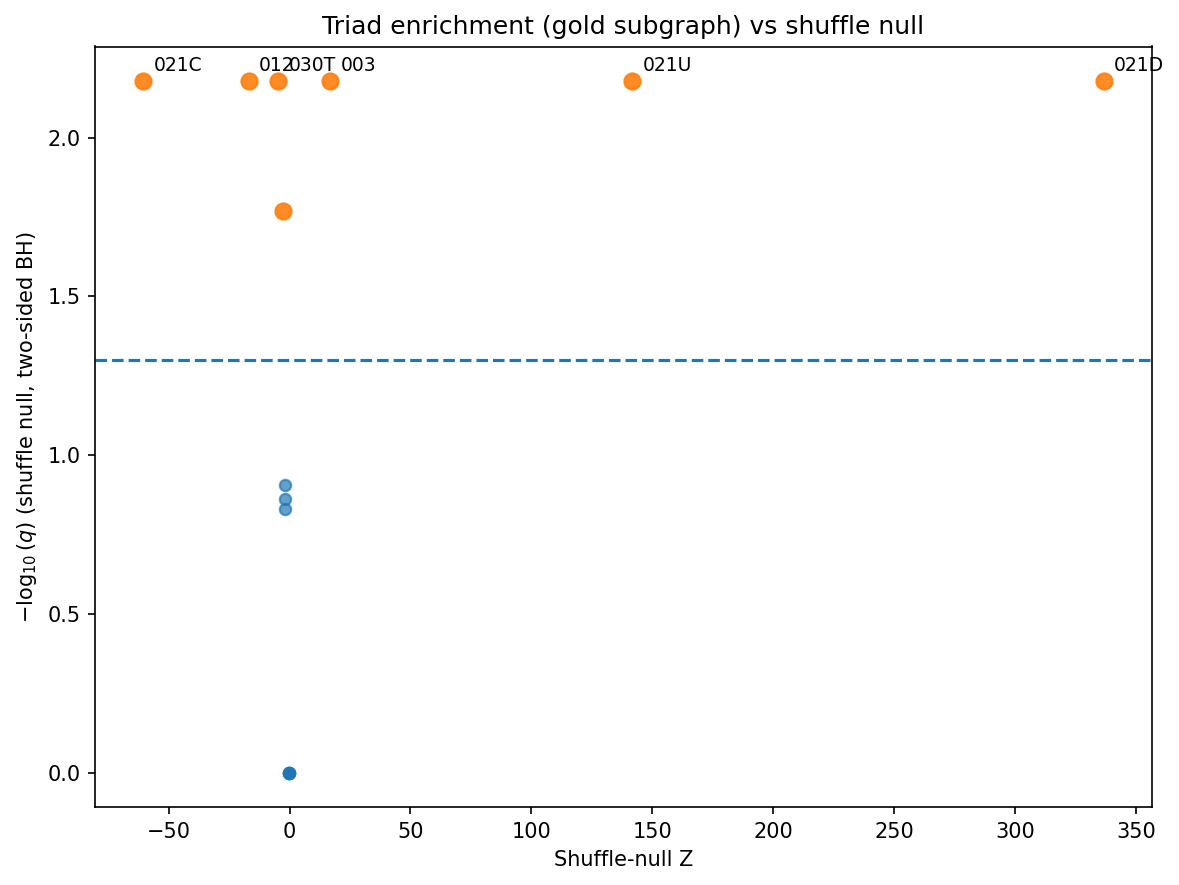

Saved volcano → PhaseB_artifacts/B7_volcano_shuffle.png


In [16]:
# === Phase B • Plots • Volcano (shuffle null) ===
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PHASEB_DIR = "PhaseB_artifacts"
os.makedirs(PHASEB_DIR, exist_ok=True)
VOLC_PATH = os.path.join(PHASEB_DIR, "B7_volcano_shuffle.png")

# Load enrichment if not present in memory
try:
    enrich_both
except NameError:
    path = os.path.join(PHASEB_DIR, "B2b_triad_enrichment_gold_both.csv")
    enrich_both = pd.read_csv(path)

df = enrich_both.copy()
df["neglog10q"] = -np.log10(np.clip(df["shuf_q_two"].astype(float), 1e-300, 1.0))
df["is_sig"] = df["shuf_q_two"] <= 0.05

plt.figure(figsize=(8,6), dpi=150)
# non-sig
mask_ns = ~df["is_sig"]
plt.scatter(df.loc[mask_ns, "shuf_Z"], df.loc[mask_ns, "neglog10q"], s=30, alpha=0.7)
# sig
mask_sig = df["is_sig"]
plt.scatter(df.loc[mask_sig, "shuf_Z"], df.loc[mask_sig, "neglog10q"], s=60, alpha=0.9)

# annotate key points (top |Z| or significant)
to_annot = pd.concat([
    df.sort_values("neglog10q", ascending=False).head(6),
    df[df["triad"].isin(["021D","021U","003"])]
]).drop_duplicates(subset=["triad"])

for _, r in to_annot.iterrows():
    plt.annotate(r["triad"], (r["shuf_Z"], r["neglog10q"]), xytext=(5,5),
                 textcoords="offset points", fontsize=9)

plt.axhline(-np.log10(0.05), ls="--")
plt.xlabel("Shuffle-null Z")
plt.ylabel(r"$-\log_{10}(q)$ (shuffle null, two-sided BH)")
plt.title("Triad enrichment (gold subgraph) vs shuffle null")
plt.tight_layout()
plt.savefig(VOLC_PATH)
plt.show()

print("Saved volcano →", VOLC_PATH)


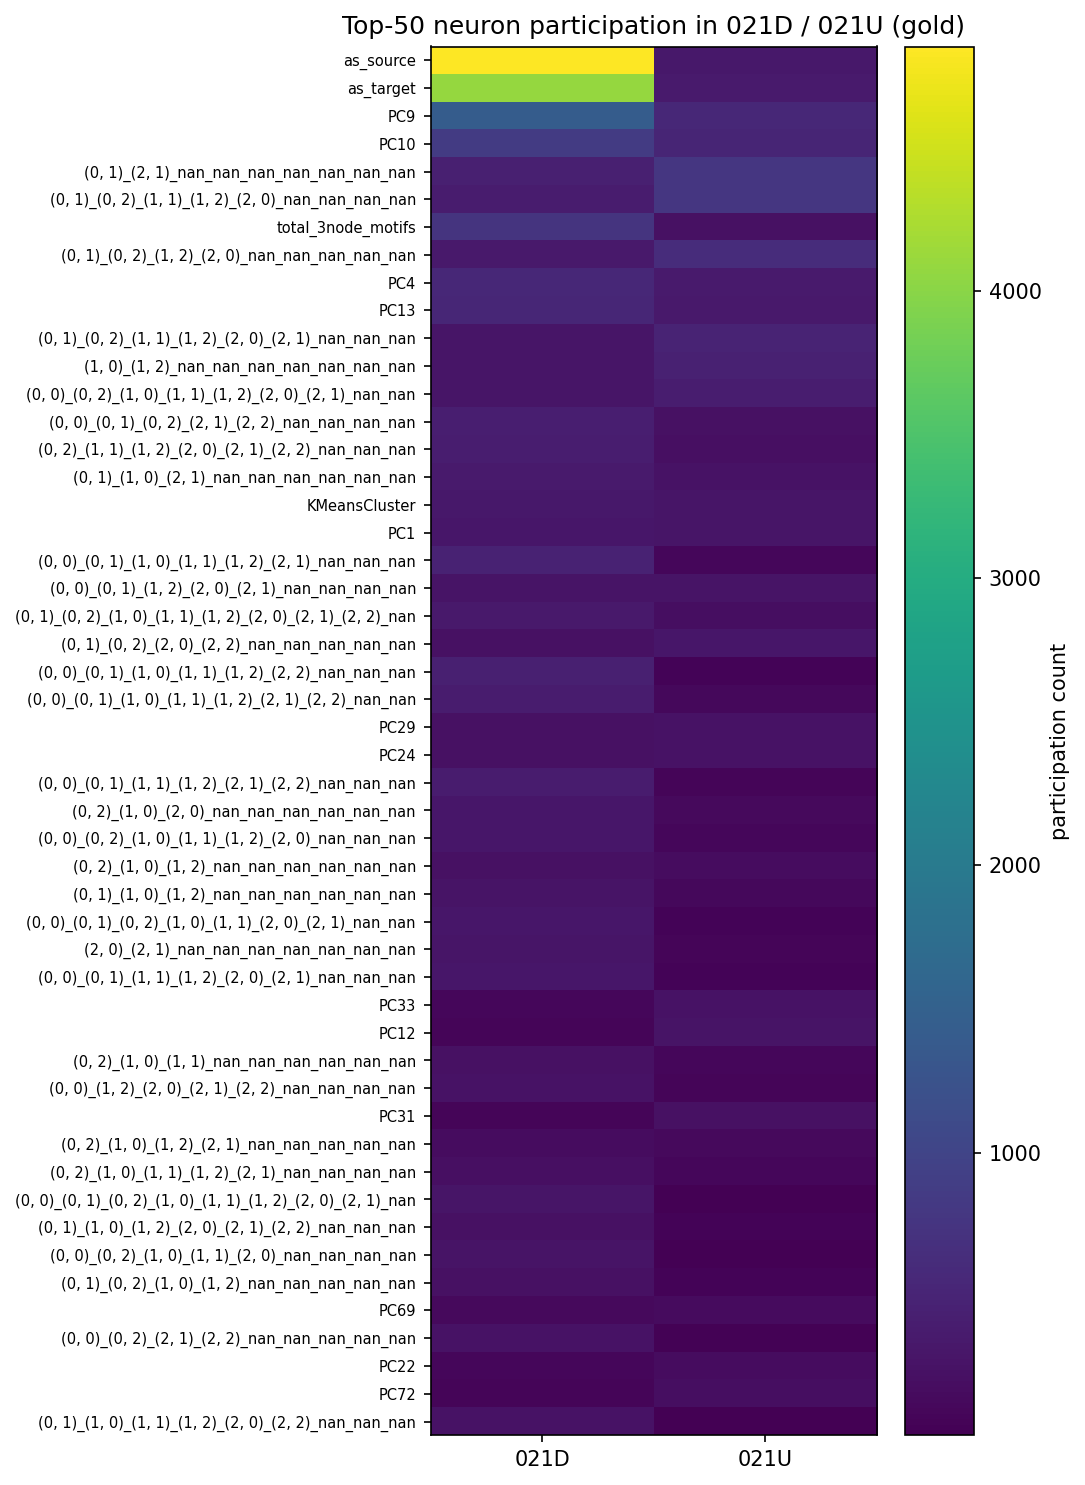

Saved heatmap → PhaseB_artifacts/B8_heatmap_021_duo.png


In [17]:
# === Phase B • Plots • Heatmap for 021D / 021U participation (top-K) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HEAT_PATH = os.path.join(PHASEB_DIR, "B8_heatmap_021_duo.png")
TOP_K = 50  # adjust if you want more/fewer rows

# Load participation if needed
try:
    gold_participation_df
except NameError:
    gold_participation_df = pd.read_csv(
        os.path.join(PHASEB_DIR, "B3_triad_participation_matrix_gold.csv"),
        index_col=0
    )

need_cols = [c for c in ["021D","021U"] if c in gold_participation_df.columns]
if len(need_cols) < 2:
    raise ValueError("Expected columns '021D' and '021U' in participation matrix.")

heat_df = gold_participation_df[need_cols].copy()
heat_df["sum_021"] = heat_df.sum(axis=1)
heat_df = heat_df.sort_values("sum_021", ascending=False).head(TOP_K).drop(columns=["sum_021"])

plt.figure(figsize=(7, max(6, TOP_K*0.2)), dpi=150)
plt.imshow(heat_df.values, aspect="auto")
plt.colorbar(label="participation count")
plt.yticks(range(len(heat_df.index)), heat_df.index, fontsize=7)
plt.xticks(range(len(need_cols)), need_cols)
plt.title(f"Top-{TOP_K} neuron participation in 021D / 021U (gold)")
plt.tight_layout()
plt.savefig(HEAT_PATH)
plt.show()

print("Saved heatmap →", HEAT_PATH)


In [18]:
# === Phase B • Tables • Top contributors (broadcast vs convergence hubs) ===
import pandas as pd
import numpy as np
import networkx as nx

OUT_D = os.path.join(PHASEB_DIR, "B9_top_participants_021D.csv")
OUT_U = os.path.join(PHASEB_DIR, "B10_top_participants_021U.csv")

# Ensure G_gold and participation loaded
try:
    G_gold
except NameError:
    # rebuild from Phase A edges if needed
    PHASEA_DIR = "PhaseA_artifacts"
    GOLD_EDGES_PATH = os.path.join(PHASEA_DIR, "A12_gold_edges_tau0.70_FDR05.csv")
    def _load_edges_csv(path):
        df = pd.read_csv(path)
        cols = [c.lower() for c in df.columns]
        if {'source','target'}.issubset(set(cols)): u,v='source','target'
        elif {'u','v'}.issubset(set(cols)): u,v='u','v'
        elif {'pre','post'}.issubset(set(cols)): u,v='pre','post'
        else: u,v=df.columns[:2]
        return df[[u,v]].rename(columns={u:'u', v:'v'})
    def _build_digraph(df_edges):
        G = nx.DiGraph()
        G.add_edges_from(df_edges[['u','v']].itertuples(index=False, name=None))
        G.remove_edges_from(nx.selfloop_edges(G))
        return G
    df_gold = _load_edges_csv(GOLD_EDGES_PATH)
    G_gold = _build_digraph(df_gold)

try:
    gold_participation_df
except NameError:
    gold_participation_df = pd.read_csv(
        os.path.join(PHASEB_DIR, "B3_triad_participation_matrix_gold.csv"),
        index_col=0
    )

df = gold_participation_df.copy()
for col in ["021D","021U"]:
    if col not in df.columns:
        df[col] = 0

# degrees
deg_in = dict(G_gold.in_degree())
deg_out = dict(G_gold.out_degree())

tab_021D = pd.DataFrame({
    "neuron": df.index,
    "count_021D": df["021D"].values,
    "out_degree": [deg_out.get(n,0) for n in df.index],
})
tab_021D["score_norm"] = tab_021D["count_021D"] / (tab_021D["out_degree"] + 1)  # avoid /0
tab_021D = tab_021D.sort_values(["count_021D","score_norm","out_degree"], ascending=[False,False,False])
tab_021D.to_csv(OUT_D, index=False)

tab_021U = pd.DataFrame({
    "neuron": df.index,
    "count_021U": df["021U"].values,
    "in_degree": [deg_in.get(n,0) for n in df.index],
})
tab_021U["score_norm"] = tab_021U["count_021U"] / (tab_021U["in_degree"] + 1)
tab_021U = tab_021U.sort_values(["count_021U","score_norm","in_degree"], ascending=[False,False,False])
tab_021U.to_csv(OUT_U, index=False)

print("Saved:")
print(" -", OUT_D, "(broadcast hubs: high 021D)")
print(" -", OUT_U, "(convergence hubs: high 021U)")
tab_021D.head(10)


Saved:
 - PhaseB_artifacts/B9_top_participants_021D.csv (broadcast hubs: high 021D)
 - PhaseB_artifacts/B10_top_participants_021U.csv (convergence hubs: high 021U)


,neuron,count_021D,out_degree,score_norm
235,as_source,4851,99,48.510000
233,as_target,4095,91,44.510870
2,PC9,1431,54,26.018182
12,PC10,861,42,20.023256
79,total_3node_motifs,741,39,18.525000
37,PC4,561,34,16.028571
4,PC13,528,33,15.529412
33,"(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 1)_nan_...",476,0,476.000000
22,"(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",448,0,448.000000
114,"(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 2)_nan_...",448,0,448.000000


In [19]:
# === Phase B • Comparison • Gold vs Full ===
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

OUT_COUNTS_CMP = os.path.join(PHASEB_DIR, "B11_compare_counts_021_duo.csv")
OUT_PART_CMP   = os.path.join(PHASEB_DIR, "B12_compare_participation_021_duo.csv")
BAR_PATH       = os.path.join(PHASEB_DIR, "B13_bar_diff_021.png")

# Try to use existing full graph results if any
full_participation_df = None
full_counts = None

# If you already ran the full-graph block earlier, we may have cmp files. Otherwise compute here if FULL_EDGES_PATH is set.
try:
    FULL_EDGES_PATH
except NameError:
    FULL_EDGES_PATH = None  # user can set this to their full edge CSV path

if FULL_EDGES_PATH and os.path.exists(FULL_EDGES_PATH):
    # helper loaders
    def _load_edges_csv(path):
        df = pd.read_csv(path)
        cols = [c.lower() for c in df.columns]
        if {'source','target'}.issubset(set(cols)): u,v='source','target'
        elif {'u','v'}.issubset(set(cols)): u,v='u','v'
        elif {'pre','post'}.issubset(set(cols)): u,v='pre','post'
        else: u,v=df.columns[:2]
        return df[[u,v]].rename(columns={u:'u', v:'v'})
    def _build_digraph(df_edges):
        G = nx.DiGraph()
        G.add_edges_from(df_edges[['u','v']].itertuples(index=False, name=None))
        G.remove_edges_from(nx.selfloop_edges(G))
        return G

    # reuse your earlier triad enumerator
    def triad_code_for_triplet(G: nx.DiGraph, a, b, c) -> str:
        H = G.subgraph([a,b,c]).copy()
        mapping = {n:i for i,n in enumerate(sorted([a,b,c], key=str))}
        H = nx.relabel_nodes(H, mapping, copy=True)
        return nx.algorithms.triads.triad_type(H)

    def per_node_triad_participation(G: nx.DiGraph):
        TRIAD_ORDER = ['003','012','102','021D','021U','021C','111D','111U',
                       '030T','030C','201','120D','120U','120C','210','300']
        nodes = list(G.nodes())
        from collections import Counter
        part = {n: Counter() for n in nodes}
        global_counts = Counter()
        import itertools as it
        for a,b,c in it.combinations(nodes, 3):
            code = triad_code_for_triplet(G, a, b, c)
            if code not in TRIAD_ORDER:
                continue
            global_counts[code] += 1
            part[a][code] += 1
            part[b][code] += 1
            part[c][code] += 1
        dfp = pd.DataFrame({n: {k: part[n].get(k,0) for k in TRIAD_ORDER} for n in nodes}).T
        dfp.index.name = "neuron"
        return dfp, dict(global_counts)

    df_full = _load_edges_csv(FULL_EDGES_PATH)
    G_full = _build_digraph(df_full)
    full_participation_df, full_counts = per_node_triad_participation(G_full)

# 4a) Counts-level comparison for 021D/021U
need = ["021D","021U"]
counts_gold = pd.read_csv(os.path.join(PHASEB_DIR,"B1_triad_counts_gold.csv"), index_col=0)
row_gold = counts_gold.loc["gold", need].astype(float) if "gold" in counts_gold.index else counts_gold.iloc[0][need].astype(float)

cmp_counts = pd.DataFrame({"gold": row_gold})
if full_counts is not None:
    cmp_counts["full"] = [full_counts.get(k,0) for k in need]
else:
    cmp_counts["full"] = np.nan

# normalize by total triads to compare proportions
if full_counts is not None:
    total_gold = counts_gold.loc["gold"].sum() if "gold" in counts_gold.index else counts_gold.sum(axis=1).iloc[0]
    total_full = sum(full_counts.values())
    cmp_counts["gold_share"] = cmp_counts["gold"] / total_gold
    cmp_counts["full_share"] = cmp_counts["full"] / total_full
    cmp_counts["log2fc_share"] = np.log2(np.clip(cmp_counts["gold_share"],1e-12,None)) - np.log2(np.clip(cmp_counts["full_share"],1e-12,None))
cmp_counts.to_csv(OUT_COUNTS_CMP)
print("Saved counts comparison →", OUT_COUNTS_CMP)

# 4b) Participation-level comparison for shared neurons (021D/021U)
try:
    gold_participation_df
except NameError:
    gold_participation_df = pd.read_csv(
        os.path.join(PHASEB_DIR, "B3_triad_participation_matrix_gold.csv"),
        index_col=0
    )

if full_participation_df is not None:
    shared = sorted(set(full_participation_df.index) & set(gold_participation_df.index))
    part_cmp = pd.DataFrame(index=shared)
    for k in need:
        part_cmp[f"gold_{k}"] = gold_participation_df.loc[shared, k].astype(float)
        part_cmp[f"full_{k}"] = full_participation_df.loc[shared, k].astype(float)
        part_cmp[f"delta_{k}"] = part_cmp[f"gold_{k}"] - part_cmp[f"full_{k}"]
        part_cmp[f"log2fc_{k}"] = np.log2(np.clip(part_cmp[f"gold_{k}"],1e-9,None)) - np.log2(np.clip(part_cmp[f"full_{k}"],1e-9,None))
    part_cmp.sort_values(["delta_021D","delta_021U"], ascending=False).to_csv(OUT_PART_CMP)
    print("Saved participation comparison →", OUT_PART_CMP)

    # simple bar for counts share difference (021D/021U)
    plt.figure(figsize=(6,4), dpi=150)
    if "gold_share" in cmp_counts.columns:
        x = np.arange(len(need))
        w = 0.35
        plt.bar(x - w/2, cmp_counts["full_share"].values, width=w, label="Full")
        plt.bar(x + w/2, cmp_counts["gold_share"].values, width=w, label="Gold")
        plt.xticks(x, need)
        plt.ylabel("Share of all triads")
        plt.title("Triad share: gold vs full (021D/021U)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(BAR_PATH)
        plt.show()
        print("Saved bar plot →", BAR_PATH)
else:
    print("Full graph not available (set FULL_EDGES_PATH). Skipped participation comparison plot.")


Saved counts comparison → PhaseB_artifacts/B11_compare_counts_021_duo.csv
Full graph not available (set FULL_EDGES_PATH). Skipped participation comparison plot.


In [23]:
# === Phase B → Phase C: Export β1 cycles (approx via undirected cycle basis) ===
import os, json
import pandas as pd
import networkx as nx

ARTB = "PhaseB_artifacts"
os.makedirs(ARTB, exist_ok=True)

def export_beta1_cycles_from_graph(G, out_prefix="B_beta1_cycles"):
    """
    Compute a cycle basis of the underlying undirected graph of G,
    treat these as β1 cycles, and export to CSV + JSON.
    """
    H = nx.Graph(G)  # underlying undirected
    cycles = nx.cycle_basis(H)  # list of lists of nodes

    # Save CSV (long format)
    rows = []
    for cid, cyc in enumerate(cycles):
        for node in cyc:
            rows.append({"cycle_id": cid, "neuron": str(node)})
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(ARTB, out_prefix + ".csv"), index=False)

    # Save JSON
    cyc_dict = {str(cid): list(map(str, cyc)) for cid, cyc in enumerate(cycles)}
    with open(os.path.join(ARTB, out_prefix + ".json"), "w") as f:
        json.dump(cyc_dict, f, indent=2)

    print(f"✅ Exported {len(cycles)} cycles to:")
    print("   -", os.path.join(ARTB, out_prefix + ".csv"))
    print("   -", os.path.join(ARTB, out_prefix + ".json"))
    return cycles

# Run on your gold graph
beta1_cycles = export_beta1_cycles_from_graph(G_gold)


✅ Exported 908 cycles to:
   - PhaseB_artifacts/B_beta1_cycles.csv
   - PhaseB_artifacts/B_beta1_cycles.json


# Phase B to C bridge

In [24]:
import os
import pandas as pd
import numpy as np
from collections import Counter

PHASEB_DIR = "PhaseB_artifacts"
os.makedirs(PHASEB_DIR, exist_ok=True)

# Uploaded files
TUPLE_TO_NEURONS = "tuple_to_neurons.csv"
TUPLE_INDEX_MAP  = "motif_tuple_index_map.tsv"
PARTICIPATION    = "motif_participation_profiles.csv"

print("Bridge config ready.")


Bridge config ready.


In [25]:
# Participation profiles: rows=neurons, cols=tuples
part_df = pd.read_csv(PARTICIPATION)
print("Participation profiles:", part_df.shape)

# Tuple index map
map_df = pd.read_csv(TUPLE_INDEX_MAP, sep="\t")
print("Tuple index map:", map_df.shape)

# Tuple → neurons mapping
tuple_neurons = pd.read_csv(TUPLE_TO_NEURONS)
print("Tuple→neurons:", tuple_neurons.shape)

# Quick checks
print("First 3 tuple labels:", map_df["tuple_label"].head().to_list())
print("First 3 neurons in participation:", part_df.iloc[:3,0].to_list())


Participation profiles: (1533, 419)
Tuple index map: (418, 4)
Tuple→neurons: (418, 2)
First 3 tuple labels: ['(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan_nan', '(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan_nan', '(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan']
First 3 neurons in participation: ['AINL', 'AINR', 'CEPshVR']


In [26]:
# Column labels in participation (excluding 'Neuron')
tuple_labels_from_part = part_df.columns[1:].to_list()
tuple_labels_from_map  = map_df["tuple_label"].to_list()

missing_in_map = set(tuple_labels_from_part) - set(tuple_labels_from_map)
missing_in_part = set(tuple_labels_from_map) - set(tuple_labels_from_part)

print("Tuple labels in participation:", len(tuple_labels_from_part))
print("Tuple labels in map:", len(tuple_labels_from_map))
print("Missing in map:", len(missing_in_map))
print("Missing in participation:", len(missing_in_part))

assert len(missing_in_map)==0 and len(missing_in_part)==0, "Mismatch between profiles and map!"


Tuple labels in participation: 418
Tuple labels in map: 418
Missing in map: 0
Missing in participation: 0


In [28]:
# Binarize participation >0
bin_part = (part_df.iloc[:, 1:] > 0).astype(int)
bin_part.index = part_df["Neuron"]

# Transpose so rows=tuple (cycle), cols=neurons
incidence = bin_part.T
incidence.index.name = "cycle_id"

# Normalize labels to ensure a clean join (remove whitespace)
inc_reset = incidence.reset_index()
inc_reset["label_norm"] = inc_reset["cycle_id"].astype(str).str.replace(r"\s+", "", regex=True)

map_norm = map_df.copy()
map_norm["label_norm"] = map_norm["tuple_label"].astype(str).str.replace(r"\s+", "", regex=True)

# Join on normalized labels to bring in tuple_index
merged = inc_reset.merge(
    map_norm[["label_norm", "tuple_index", "tuple_label"]],
    on="label_norm",
    how="left",
)

# Safety check
missing_idx = merged["tuple_index"].isna().sum()
if missing_idx > 0:
    print(f"[warn] {missing_idx} tuples did not map to a tuple_index; inspect label normalization.")

# Finalize: set index to integer tuple_index and drop helper cols
incidence = (
    merged.drop(columns=["label_norm", "tuple_label"])
          .set_index("tuple_index")
          .sort_index()
)

print("Incidence matrix shape:", incidence.shape)
print("Example incidence row:\n", incidence.iloc[0, :10])


Incidence matrix shape: (418, 1534)
Example incidence row:
 cycle_id    (0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...
AINL                                                        0
AINR                                                        0
CEPshVR                                                     1
CEPshDL                                                     0
CEPshVL                                                     0
ASIR                                                        0
CEPshDR                                                     0
ASJR                                                        0
PVT                                                         0
Name: 0, dtype: object


In [30]:
# --- Sanitize incidence to be strictly numeric in neuron columns ---
# Drop any non-numeric helper columns if they slipped through (e.g., "cycle_id")
non_numeric_cols = [c for c in incidence.columns if not np.issubdtype(incidence[c].dtype, np.number)]
if non_numeric_cols:
    # Keep them aside just in case you want to inspect later
    print("[info] Dropping non-numeric columns from incidence:", non_numeric_cols)
    incidence = incidence.drop(columns=non_numeric_cols)

# Ensure all remaining columns are 0/1 ints
incidence = incidence.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

# --- Write artifacts ---
inc_path = os.path.join(PHASEB_DIR, "B_beta1_incidence.csv")
incidence.to_csv(inc_path)

# Cycle ID → label
map_out = map_df[["tuple_index", "tuple_label"]].drop_duplicates().sort_values("tuple_index")
map_out_path = os.path.join(PHASEB_DIR, "B_beta1_cycle_id_to_label.csv")
map_out.to_csv(map_out_path, index=False)

# Cycle sizes (numeric-only)
sizes = incidence.sum(axis=1).astype(int)
size_df = pd.DataFrame({"cycle_id": incidence.index, "size": sizes})
size_out_path = os.path.join(PHASEB_DIR, "B_beta1_cycle_sizes.csv")
size_df.to_csv(size_out_path, index=False)

print("Artifacts written:")
print(" -", inc_path)
print(" -", map_out_path)
print(" -", size_out_path)


[info] Dropping non-numeric columns from incidence: ['cycle_id']
Artifacts written:
 - PhaseB_artifacts/B_beta1_incidence.csv
 - PhaseB_artifacts/B_beta1_cycle_id_to_label.csv
 - PhaseB_artifacts/B_beta1_cycle_sizes.csv


In [31]:
sizes = incidence.sum(axis=1).values
print("Cycle size stats:")
print(" - min:", sizes.min())
print(" - median:", int(np.median(sizes)))
print(" - max:", sizes.max())
print(" - P10/P25/P75/P90:",
      np.percentile(sizes, [10,25,75,90]).astype(int).tolist())
print(" - ≥100 neurons:", np.sum(sizes>=100))
print(" - ≥500 neurons:", np.sum(sizes>=500))

# Check agreement with tuple_to_neurons file
sample = tuple_neurons.sample(5, random_state=42)
for _, row in sample.iterrows():
    tidx = row["tuple_index"]
    listed = set(str(row["neurons"]).split(";"))
    inc_members = set(incidence.loc[tidx][incidence.loc[tidx]==1].index)
    print(f"Tuple {tidx} | listed={len(listed)} inc={len(inc_members)} overlap={len(listed & inc_members)}")


Cycle size stats:
 - min: 3
 - median: 45
 - max: 1343
 - P10/P25/P75/P90: [8, 19, 102, 149]
 - ≥100 neurons: 110
 - ≥500 neurons: 6
Tuple 8 | listed=14 inc=14 overlap=14
Tuple 326 | listed=6 inc=6 overlap=6
Tuple 159 | listed=9 inc=9 overlap=9
Tuple 122 | listed=153 inc=153 overlap=153
Tuple 104 | listed=80 inc=80 overlap=80
